In [5]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
from skimage.io import imread

json_path = Path("/net/projects2/promega/data-analysis/output/all_data.json")

with open(json_path, "r") as f:
    data = json.load(f)

# 1. Quantitative: all masks with edge_fraction > 0.2
high_edge = {
    k: v for k, v in data.items()
    if isinstance(v, dict) and v.get("edge_fraction", 0) is not None and v["edge_fraction"] > 0.2
}
print(f"Found {len(high_edge)} entries with edge_fraction > 0.2")

# Just show a few keys and values as a test
for i, (k, v) in enumerate(high_edge.items()):
    if i >= 10: break
    print(f"{k}: edge_fraction={v['edge_fraction']:.3f}")

# 2. Qualitative: stitched entries only
stitched = {
    k: v for k, v in data.items()
    if isinstance(v, dict) and v.get("Classification", "").lower() == "stitched"
}

print(f"Found {len(stitched)} stitched entries")

def show_overlay(img_path, mask_path, title=None):
    try:
        img = imread(img_path)
    except Exception as e:
        print(f"⚠️ Could not load image {img_path}: {e}")
        return
    try:
        mask = imread(mask_path)
        if mask.ndim == 3:
            mask = mask[..., 0]
    except Exception as e:
        print(f"⚠️ Could not load mask {mask_path}: {e}")
        return
    
    plt.figure(figsize=(8,8))
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, cmap="Reds", alpha=0.4)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

# Show overlays for first 3 stitched entries
for i, (k, v) in enumerate(stitched.items()):
    if i >= 3: break
    mask_path = v.get("processed", {}).get("mask_path")
    img_path  = v.get("processed", {}).get("img_path")
    if mask_path and img_path:
        print(f"Overlay for {k}")
        show_overlay(img_path, mask_path, title=f"{k} (edge_fraction={v.get('edge_fraction')})")


KeyError: 'edge_fraction'

In [3]:
import json
from pathlib import Path

json_path = Path("/net/projects2/promega/data-analysis/output/all_data.json")

with open(json_path, "r") as f:
    data = json.load(f)

# Optional: get base_folder if you need to absolutize relative paths later
base_folder = (
    data.get("_meta", {})
        .get("base_mapper", {})
        .get("_base_folder")
)

def is_entry(k, v):
    return isinstance(k, str) and k.upper().startswith("BA") and isinstance(v, dict)

def ef_value(v):
    val = v.get("edge_fraction", None)
    return float(val) if isinstance(val, (int, float)) else None

# Filter safely (no KeyError)
high_edge = {
    k: v for k, v in data.items()
    if is_entry(k, v) and (ef_value(v) is not None) and ef_value(v) > 0.2
}

print(f"Found {len(high_edge)} entries with edge_fraction > 0.2")

# Peek a few examples
for i, (k, v) in enumerate(high_edge.items()):
    if i >= 10: break
    print(f"{k}: edge_fraction={ef_value(v):.3f}, has_mask={'processed' in v and 'mask_path' in v['processed']}")


Found 23 entries with edge_fraction > 0.2
BA2 96_1 Dy24 D7: edge_fraction=0.293, has_mask=True
BA1 96_1 Dy28 A12: edge_fraction=0.235, has_mask=True
BA1 96_1 Dy28 H8: edge_fraction=0.220, has_mask=True
BA1 96_1 Dy28 H9: edge_fraction=0.218, has_mask=True
BA2 96_1 Dy28 A12: edge_fraction=0.306, has_mask=True
BA2 96_1 Dy28 A2: edge_fraction=0.200, has_mask=True
BA2 96_1 Dy28 A5: edge_fraction=0.304, has_mask=True
BA2 96_1 Dy28 A9: edge_fraction=0.244, has_mask=True
BA2 96_1 Dy28 C5: edge_fraction=0.261, has_mask=True
BA2 96_1 Dy28 C7: edge_fraction=0.294, has_mask=True


In [ ]:
import matplotlib.pyplot as plt
from skimage.io import imread
import numpy as np
from pathlib import Path

def to_abs(p: str | None):
    """Turn relative path into absolute with base_folder, pass through absolute paths."""
    if not p: 
        return None
    pp = Path(p)
    if pp.is_absolute() or not base_folder:
        return str(pp)
    return str(Path(base_folder) / pp)

def show_overlay(img_path, mask_path, title=None):
    try:
        img = imread(img_path)
    except Exception as e:
        print(f"⚠️ Could not load image {img_path}: {e}")
        return
    try:
        mask = imread(mask_path)
        if mask.ndim == 3:
            mask = mask[..., 0]
        mask = (mask > 0).astype(np.uint8)
    except Exception as e:
        print(f"⚠️ Could not load mask {mask_path}: {e}")
        return

    plt.figure(figsize=(8,8))
    # don't force grayscale if original is rgb
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.imshow(mask, cmap="Reds", alpha=0.4)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

# stitched-only subset
stitched = {
    k: v for k, v in data.items()
    if is_entry(k, v) and v.get("Classification", "").lower() == "stitched"
}

print(f"Found {len(stitched)} stitched entries")

# Show overlays for first N stitched entries that have both paths
N = 15
shown = 0
for k, v in stitched.items():
    proc = v.get("processed", {})
    img_path  = to_abs(proc.get("img_path")) or to_abs(v.get("Best Z Filename"))
    mask_path = to_abs(proc.get("mask_path"))
    if img_path and mask_path:
        ef = ef_value(v)
        title = f"{k}  ef={ef:.3f}" if ef is not None else k
        print(f"Overlay: {k}")
        show_overlay(img_path, mask_path, title=title)
        shown += 1
        if shown >= N:
            break

if shown == 0:
    print("No stitched entries with both img_path and mask_path found to display.")


Found 39 stitched entries
Overlay: BA2 96_1 Dy24 H6


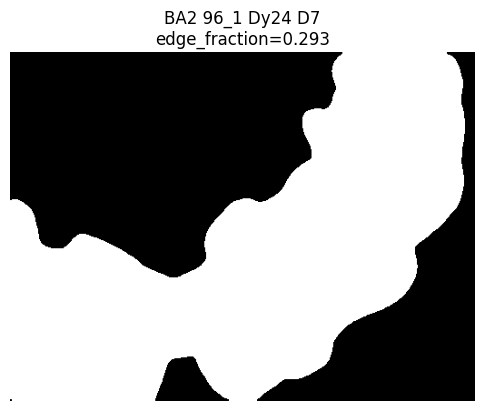

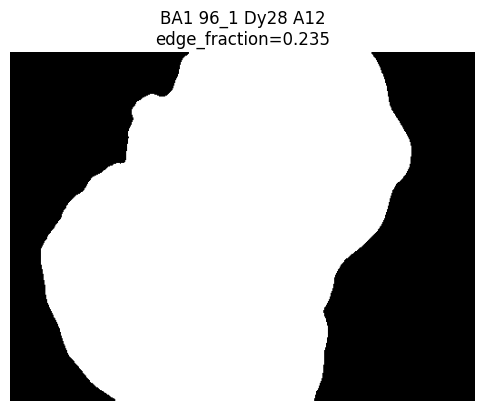

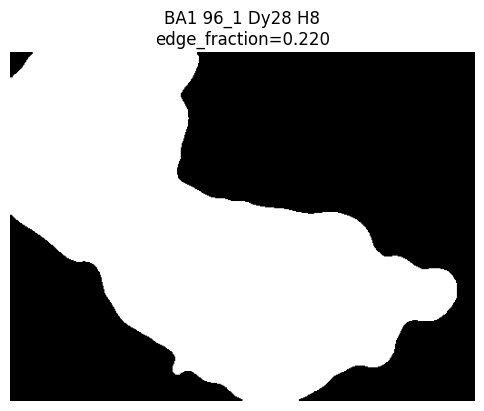

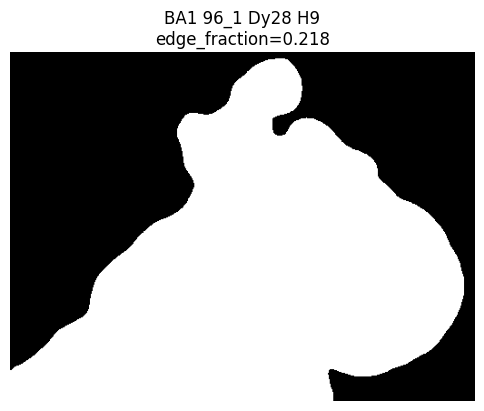

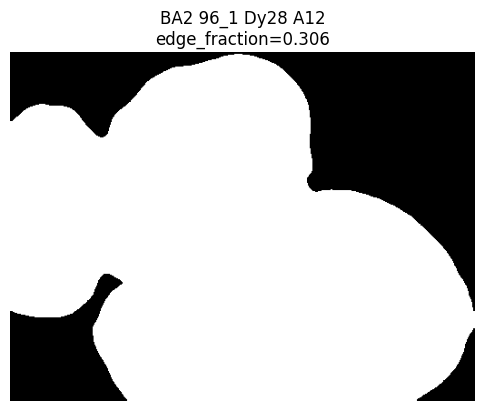

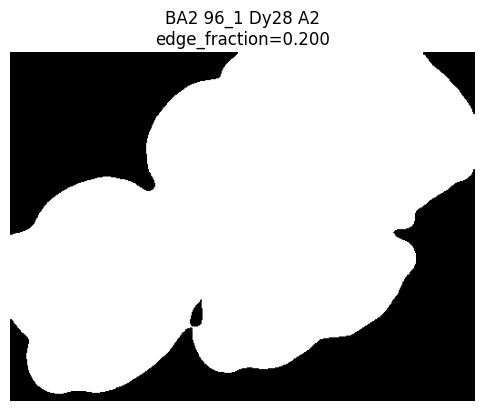

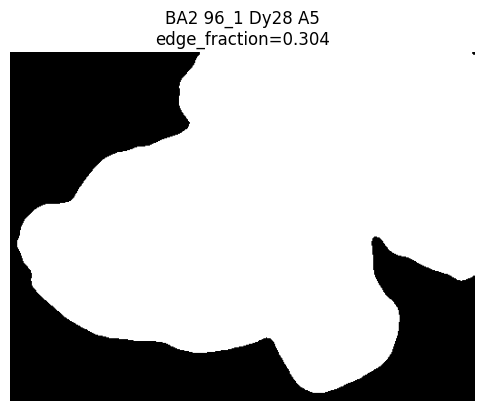

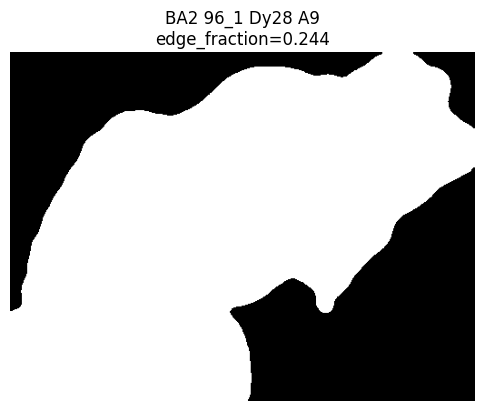

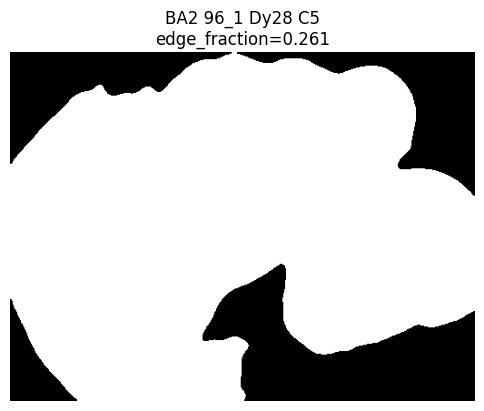

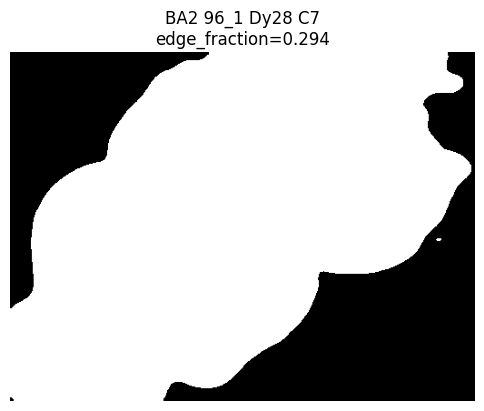

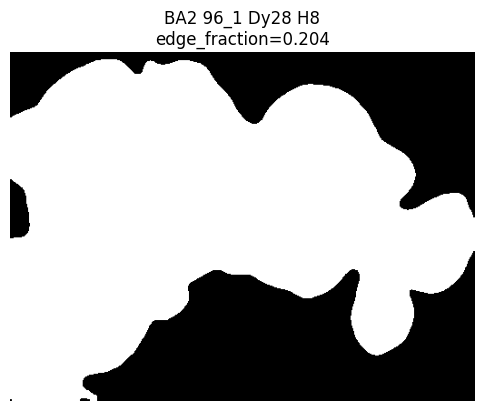

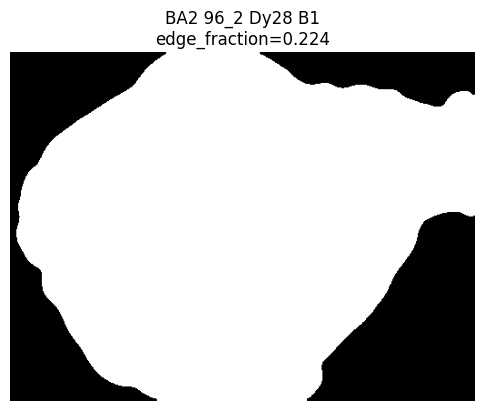

In [6]:
import matplotlib.pyplot as plt
from skimage.io import imread
import numpy as np
from pathlib import Path

# assumes: data, base_folder, high_edge are already defined as in your cell

def to_abs(p):
    if not p:
        return None
    pp = Path(p)
    if pp.is_absolute() or not base_folder:
        return str(pp)
    return str(Path(base_folder) / pp)

def load_mask_img(mask_path: str):
    arr = imread(mask_path)
    if arr.ndim == 3:
        arr = arr[..., 0]
    return (arr > 0).astype(np.uint8)

N = 12  # how many to preview
shown = 0

for k, v in high_edge.items():
    mpath = v.get("processed", {}).get("mask_path")
    if not mpath:
        continue
    mpath = to_abs(mpath)
    try:
        mask = load_mask_img(mpath)
    except Exception as e:
        print(f"⚠️ {k}: failed to load {mpath} -> {e}")
        continue

    plt.figure(figsize=(6,6))
    plt.imshow(mask, cmap="gray")
    ef = v.get("edge_fraction")
    plt.title(f"{k}\nedge_fraction={ef:.3f}" if isinstance(ef, (int,float)) else k)
    plt.axis("off")
    plt.show()

    shown += 1
    if shown >= N:
        break

if shown == 0:
    print("No masks found to display from high_edge.")
